## __Selecting studies__

In [2]:
import pandas as pd
import webbrowser
import time
from pathlib import Path

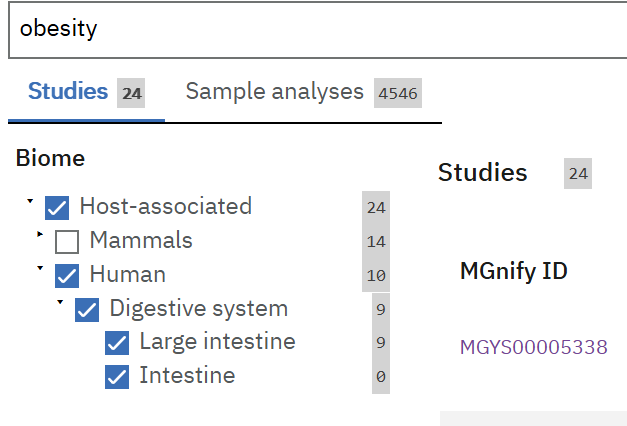

In [3]:
obese = pd.read_csv('../data/raw/search_download_obese.csv',header=0)
park = pd.read_csv('../data/raw/search_download_parkinson.csv',header=0)

In [4]:
df = pd.concat([obese,park],ignore_index=True)

In [5]:
def open_studies(project_ids):
    webbrowser.open_new(f'https://www.ebi.ac.uk/metagenomics/studies/{project_ids[0]}#overview')
    for id in project_ids[1:]: 
        url = f'https://www.ebi.ac.uk/metagenomics/studies/{id}#overview'
        time.sleep(0.2)
        webbrowser.open_new_tab(url)

In [6]:
#open_studies(df['ENA_PROJECT'])

In [7]:
with open(Path('../data/processed/MGnify_selected_studies.txt'),'r') as file:
    text = file.read()

lista = text.split('\n')


In [8]:
#open_studies(lista)

## __Creating pipeline__

File = 'C:/Users/34640/AppData/Local/Temp/2cce0c41-d362-4dce-83dd-721c7167a3c5_ERZ650890_FASTA_emapper.annotations.tsv.gz.3c5/ERZ650890_FASTA.emapper.annotations'

Estudio = Study MGYS00005333

EMG produced TPA metagenomics assembly of the Gut microbial dysbiosis in young adults with obesity (Gut microbial dysbiosis in young adults with obesity) data set.

Archivo = Buscar pero puede ser el eggNOG annotations of the protein coding sequences

https://amigo.geneontology.org/amigo/term/GO:0000105

__El estudio para el cual voy  a crear la pipeline es el Gut microbial dysbiosis in young adults with obesity (MGYS00005333)__

In [2]:
import pandas as pd

In [10]:
samples = pd.read_csv('../data/raw/MGnify_samples_list.csv')

In [11]:
samples.head()

,accession,analysis_status,analysis_summary.0.key,analysis_summary.0.value,analysis_summary.1.key,analysis_summary.1.value,analysis_summary.10.key,analysis_summary.10.value,analysis_summary.11.key,analysis_summary.11.value,...,instrument_model,instrument_platform,is_private,last_update,mgx_accession,pipeline_version,run,sample,study,url
0,MGYA00721508,completed,Submitted nucleotide sequences,82662,Nucleotide sequences after format-specific fil...,82662,Reads with predicted CDS,82473,Reads with predicted RNA,2146,...,Illumina HiSeq 2500,ILLUMINA,False,2024-02-05T22:52:03.219552,NaN,5.0,NaN,https://www.ebi.ac.uk/metagenomics/api/v1/samp...,https://www.ebi.ac.uk/metagenomics/api/v1/stud...,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
1,MGYA00721516,completed,Submitted nucleotide sequences,42326,Nucleotide sequences after format-specific fil...,42326,Reads with predicted CDS,42223,Reads with predicted RNA,1219,...,Illumina HiSeq 2500,ILLUMINA,False,2024-02-05T23:02:32.942253,NaN,5.0,NaN,https://www.ebi.ac.uk/metagenomics/api/v1/samp...,https://www.ebi.ac.uk/metagenomics/api/v1/stud...,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
2,MGYA00721520,completed,Submitted nucleotide sequences,95056,Nucleotide sequences after format-specific fil...,95056,Reads with predicted CDS,94853,Reads with predicted RNA,2202,...,Illumina HiSeq 2500,ILLUMINA,False,2024-02-05T23:08:50.351371,NaN,5.0,NaN,https://www.ebi.ac.uk/metagenomics/api/v1/samp...,https://www.ebi.ac.uk/metagenomics/api/v1/stud...,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
3,MGYA00721526,completed,Submitted nucleotide sequences,89601,Nucleotide sequences after format-specific fil...,89601,Reads with predicted CDS,89380,Reads with predicted RNA,2065,...,Illumina HiSeq 2500,ILLUMINA,False,2024-02-05T23:19:43.028572,NaN,5.0,NaN,https://www.ebi.ac.uk/metagenomics/api/v1/samp...,https://www.ebi.ac.uk/metagenomics/api/v1/stud...,https://www.ebi.ac.uk/metagenomics/api/v1/anal...
4,MGYA00721533,completed,Submitted nucleotide sequences,90747,Nucleotide sequences after format-specific fil...,90747,Reads with predicted CDS,90564,Reads with predicted RNA,2017,...,Illumina HiSeq 2500,ILLUMINA,False,2024-02-05T23:30:19.018166,NaN,5.0,NaN,https://www.ebi.ac.uk/metagenomics/api/v1/samp...,https://www.ebi.ac.uk/metagenomics/api/v1/stud...,https://www.ebi.ac.uk/metagenomics/api/v1/anal...


In [12]:
samples_list = samples['accession'].to_list()

In [13]:
len(samples_list)

239

In [14]:
import requests

def request_data(project_ids,path,filename):
    import os, time, re

    if not os.path.exists(path/filename):
        print(f'Creating {filename}...\n')
        file = open(path/filename,'a')
        file.close()
    else:
        print(f'{filename} was already created')

    with open(path/filename, 'r') as file:
        regex = re.compile(r'MGYA\d{8}')
        text = file.read()
        already_in = regex.findall(text)

    for index,id in enumerate(project_ids,1):
        clean_id = str(id).strip()
        if clean_id not in already_in:
            url = f'https://www.ebi.ac.uk/metagenomics/api/v1/analyses/{clean_id}/downloads'
            try:
                response = requests.get(url,timeout=30)
                time.sleep(3)

                if response.status_code == 200:
                    data = response.json()

                    link = None

                    for i,key in enumerate(data.get('data',[]),0):
                        name = key.get('id',None)
                        if name and name.endswith('_FASTA_emapper.annotations.tsv.gz'):
                            link = data['data'][i]['links']['self']
                            with open(path/filename,'a') as file:
                                print(f'Writing link for sample with accesion code: {clean_id}...')
                                file.write(link+'\n')
                            break
                else:
                    print(f"Error descargando {clean_id}: Código {response.status_code}")

            except requests.exceptions.RequestException as e:
                print(f"The server took too much time with {clean_id}! Aborting due to {e} and asking for the next one...")
        else:
            print(f"{clean_id}'link is already in the file... Skipping...")


In [15]:
{'type': 'analysis-job-downloads',    
 'id': 'ERZ650890_FASTA_emapper.annotations.tsv.gz',    
 'attributes': {'alias': 'ERZ650890_FASTA_emapper.annotations.tsv.gz',     
                'file-format': {'name': 'TSV', 
                                'extension': 'tsv', 
                                'compression': True},     
                                'description': {'label': 'eggNOG annotation',      
                                                'description': 'eggNOG annotations of the protein coding sequences'},     
                                                'group-type': 'Functional analysis',     
                                                'file-checksum': {'checksum': '', 
                                                                  'checksum-algorithm': ''}},    
                                                'relationships': {'pipeline': {'data': {'type': 'pipelines', 
                                                                                                          'id': '5.0'},      
                                                                                                          'links': {'related': 'https://www.ebi.ac.uk/metagenomics/api/v1/pipelines/5.0'}}},    
 'links': {'self': 'https://www.ebi.ac.uk/metagenomics/api/v1/analyses/MGYA00721508/file/ERZ650890_FASTA_emapper.annotations.tsv.gz'}}

{'type': 'analysis-job-downloads',
 'id': 'ERZ650890_FASTA_emapper.annotations.tsv.gz',
 'attributes': {'alias': 'ERZ650890_FASTA_emapper.annotations.tsv.gz',
  'file-format': {'name': 'TSV', 'extension': 'tsv', 'compression': True},
  'description': {'label': 'eggNOG annotation',
   'description': 'eggNOG annotations of the protein coding sequences'},
  'group-type': 'Functional analysis',
  'file-checksum': {'checksum': '', 'checksum-algorithm': ''}},
 'relationships': {'pipeline': {'data': {'type': 'pipelines', 'id': '5.0'},
   'links': {'related': 'https://www.ebi.ac.uk/metagenomics/api/v1/pipelines/5.0'}}},
 'links': {'self': 'https://www.ebi.ac.uk/metagenomics/api/v1/analyses/MGYA00721508/file/ERZ650890_FASTA_emapper.annotations.tsv.gz'}}

In [16]:
from pathlib import Path
path = Path('../data/raw')
request_data(samples_list,path,'links.txt')

links.txt was already created
MGYA00721508'link is already in the file... Skipping...
MGYA00721516'link is already in the file... Skipping...
MGYA00721520'link is already in the file... Skipping...
MGYA00721526'link is already in the file... Skipping...
The server took too much time with MGYA00721533! Aborting due to HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=30) and asking for the next one...
Writing link for sample with accesion code: MGYA00721539...
The server took too much time with MGYA00721541! Aborting due to HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=30) and asking for the next one...
The server took too much time with MGYA00721546! Aborting due to HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=30) and asking for the next one...
Writing link for sample with accesion code: MGYA00721550...
The server took too much time with MGYA00721555! Aborting due to HTTPSConnect

In [18]:
def request_data(project_ids,path,filename):
    import os, time, re, requests

    if not os.path.exists(path/filename):
        print(f'Creating {filename}...\n')
        file = open(path/filename,'a')
        file.close()
    else:
        print(f'{filename} was already created')

    already_in = []
    loop_limit = 0

    while len(already_in) != len(project_ids) and loop_limit <6:

        with open(path/filename, 'r') as file:
            regex = re.compile(r'MGYA\d{8}')
            text = file.read()
            already_in = list(set(regex.findall(text)))

        for index,id in enumerate(project_ids,1):
            clean_id = str(id).strip()
            if clean_id not in already_in:
                url = f'https://www.ebi.ac.uk/metagenomics/api/v1/analyses/{clean_id}/downloads'
                try:
                    response = requests.get(url,timeout=30)
                    time.sleep(3)

                    if response.status_code == 200:
                        data = response.json()

                        link = None

                        for i,key in enumerate(data.get('data',[]),0):
                            name = key.get('id',None)
                            if name and name.endswith('_FASTA_emapper.annotations.tsv.gz'):
                                link = data['data'][i]['links']['self']
                                with open(path/filename,'a') as file:
                                    print(f'Writing link for sample with accesion code: {clean_id}...')
                                    file.write(link+'\n')
                                break
                    else:
                        print(f"Error descargando {clean_id}: Código {response.status_code}")

                except requests.exceptions.RequestException as e:
                    print(f"The server took too much time with {clean_id}! Aborting due to {e} and asking for the next one...")
        #else:
            #print(f"{clean_id}'link is already in the file... Skipping...")
        
        loop_limit+=1


In [19]:
from pathlib import Path
path = Path('../data/raw')
request_data(samples_list,path,'links.txt')

links.txt was already created
Writing link for sample with accesion code: MGYA00721533...
Writing link for sample with accesion code: MGYA00721541...
Writing link for sample with accesion code: MGYA00721546...
Writing link for sample with accesion code: MGYA00721555...
The server took too much time with MGYA00721559! Aborting due to HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=30) and asking for the next one...
Writing link for sample with accesion code: MGYA00721564...
Writing link for sample with accesion code: MGYA00721572...
Writing link for sample with accesion code: MGYA00721576...
Writing link for sample with accesion code: MGYA00721586...
Writing link for sample with accesion code: MGYA00721593...
The server took too much time with MGYA00721599! Aborting due to HTTPSConnectionPool(host='www.ebi.ac.uk', port=443): Read timed out. (read timeout=30) and asking for the next one...
Writing link for sample with accesion code: MGYA00721601...
Writ

In [3]:
annotations = pd.read_csv('../data/raw/MGYA00721508/ERZ650890_FASTA_emapper.annotations.tsv/ERZ650890_FASTA.emapper.annotations',sep='\t',header=None)

In [6]:
annotations.iloc[1,:]

0     ERZ650890.3258-NODE-3258-length-11858-cov-9.07...
1                             1122217.KB899580_gene1642
2                                                   0.0
3                                                 535.0
4                                         Negativicutes
5                                                  yddR
6                                                   NaN
7                                                   NaN
8                                                   NaN
9                                                   NaN
10                                                  NaN
11                                                  NaN
12                                                  NaN
13                                                  NaN
14                                                  NaN
15                                                  NaN
16                                                  NaN
17                                             B

In [4]:
annotations.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,ERZ650890.3258-NODE-3258-length-11858-cov-9.07...,1122217.KB899580_gene1641,5.800000e-49,199.9,Bacteria,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bacteria,"COG1733@1,COG1733@2",NA|NA|NA,K,regulation of RNA biosynthetic process
1,ERZ650890.3258-NODE-3258-length-11858-cov-9.07...,1122217.KB899580_gene1642,2.000000e-149,535.0,Negativicutes,yddR,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bacteria,"1TSSV@1239,4H1WT@909932,COG2220@1,COG2220@2",NA|NA|NA,S,Beta-lactamase superfamily domain
2,ERZ650890.3258-NODE-3258-length-11858-cov-9.07...,1122217.KB899580_gene1643,0.000000e+00,1571.2,Negativicutes,actP,"GO:0005575,GO:0005623,GO:0005886,GO:0016020,GO...","3.6.3.4,3.6.3.54","ko:K01533,ko:K17686","ko01524,ko04016,map01524,map04016",...,RC00002,"ko00000,ko00001,ko01000",3.A.3.5,NaN,NaN,Bacteria,"1TP5S@1239,4H1XF@909932,COG2217@1,COG2217@2",NA|NA|NA,P,Copper-exporting ATPase
3,ERZ650890.3258-NODE-3258-length-11858-cov-9.07...,1122217.KB899580_gene1644,2.000000e-102,379.0,Negativicutes,NaN,NaN,3.5.2.6,"ko:K02172,ko:K17838","ko01501,map01501",...,RC01499,"ko00000,ko00001,ko00002,ko01000,ko01002,ko01504",NaN,NaN,NaN,Bacteria,"1VZ0X@1239,4H3EP@909932,COG2602@1,COG2602@2",NA|NA|NA,M,Penicillin binding protein transpeptidase domain
4,ERZ650890.3258-NODE-3258-length-11858-cov-9.07...,1122217.KB899580_gene1645,6.900000e-199,699.9,Negativicutes,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bacteria,"1TRNU@1239,4H926@909932,COG0477@1,COG2814@2",NA|NA|NA,EGP,Major Facilitator Superfamily


In [5]:
annotations.shape

(240340, 22)

In [6]:
annotations.describe()



,2,3
count,2.403400e+05,240340.000000
mean,2.747981e-09,416.054753
std,5.196519e-08,336.839601
min,0.000000e+00,60.100000
25%,3.000000e-152,181.000000
50%,6.250000e-87,327.000000
75%,3.500000e-43,544.700000
max,7.000000e-06,5969.400000


In [7]:
df = annotations[[4,5]]

In [8]:
df.isna().sum()

4         0
5    114183
dtype: int64

In [9]:
df_clean = df.dropna(subset=[5])

In [10]:
df_clean.shape

(126157, 2)

In [11]:
huth = df_clean[df_clean[5].str.contains('huth',case=False) | df_clean[5].str.contains('hystidine',case=False)]

In [12]:
huth[4].value_counts()

4
Bacteroidaceae                  10
Rikenellaceae                    4
Porphyromonadaceae               3
Bacteroidia                      2
Oscillospiraceae                 2
Firmicutes                       2
Clostridiales incertae sedis     1
Bacteria                         1
Eubacteriaceae                   1
unclassified Burkholderiales     1
Betaproteobacteria               1
Blautia                          1
Bifidobacteriales                1
Name: count, dtype: int64

In [13]:
huth.head()

,4,5
4898,Bacteroidaceae,hutH
20674,Bacteroidaceae,hutH
25248,Bacteria,hutH
33715,Bacteroidaceae,hutH
37887,Clostridiales incertae sedis,hutH


## __Analyzing downloaded samples__

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
links_file = Path('../data/raw/links.txt')

with open(links_file,'r') as file:
    links_list = [i for i in file.read().strip().split('\n')]

In [4]:
len(links_list)

239

In [5]:
df = pd.read_csv(links_list[0],sep='\t',compression='gzip',header=None)

In [6]:
df.loc[:,[4,5]]

,4,5
0,Bacteria,NaN
1,Negativicutes,yddR
2,Negativicutes,actP
3,Negativicutes,NaN
4,Negativicutes,NaN
...,...,...
240335,Clostridia,NaN
240336,Eubacteriaceae,enhA_2
240337,Desulfovibrionales,cobU
240338,Clostridia,NaN


In [11]:
def construct_huth_df(links,folder_path,filename):
    import re, os
    from urllib import error
    from pathlib import Path
    
    analysis_re = re.compile(r'MGYA\d{8}')
    sample_re = re.compile(r'ERZ\d+')

    file_path = Path(folder_path)/Path(filename)

    if not os.path.exists(file_path):
        print(f'Creating {filename}...\n')
        file = open(file_path,'w')
        file.write('bacteria,huth,analysis,sample\n')
        file.close()
    else:
        print(f'{filename} was already created')
         

    for link in links:
        analysis_id = analysis_re.search(link).group()
        sample_id = sample_re.search(link).group()
        try:
            df = pd.read_csv(link,sep='\t',compression='gzip',header=None)

            df = df.loc[:,[4,5]]
            df_clean = df.dropna(subset=[5])
            huth = df_clean[df_clean[5].str.contains('huth',case=False) | df_clean[5].str.contains('histidine',case=False)].copy()
            huth['bacteria'] = huth[4]
            huth['huth'] = huth[5]
            huth['analysis'] = analysis_id
            huth['sample'] = sample_id
            huth.drop(columns=[4,5],inplace=True)

            huth.to_csv(file_path,mode='a',header=False,index=False)
            print(f'Analysis with id: {analysis_id} was downloaded succesfully!')
            

        except error.HTTPError as e:
                if e.code == 500:
                    print(f"The server failed to extract the analysis {analysis_id}! Aborting due to {e} and asking for the next one...")
                elif e.code == 404:
                    print(f"The server failed to extract the analysis {analysis_id} due to {e} because it doesn't exists!")
                else:
                     print(f'The extraction failed due to {e}')
        
        except Exception as e:
            print(f'Unexpected error with {analysis_id}: {e}')
                     

In [16]:
from pathlib import Path
path = Path('../data/processed/huth_count_obesity_1')
construct_huth_df(links_list,folder_path='../data/processed/huth_count_obesity_1',filename='huth_count_obesity_1.csv')

Creating huth_count_obesity_1.csv...

Analysis with id: MGYA00721508 was downloaded succesfully!
Analysis with id: MGYA00721516 was downloaded succesfully!
Analysis with id: MGYA00721520 was downloaded succesfully!
Analysis with id: MGYA00721526 was downloaded succesfully!
Analysis with id: MGYA00721539 was downloaded succesfully!
Analysis with id: MGYA00721550 was downloaded succesfully!
Analysis with id: MGYA00721588 was downloaded succesfully!
Analysis with id: MGYA00721607 was downloaded succesfully!
Analysis with id: MGYA00721626 was downloaded succesfully!
Analysis with id: MGYA00721633 was downloaded succesfully!
Analysis with id: MGYA00721643 was downloaded succesfully!
Analysis with id: MGYA00721657 was downloaded succesfully!
Analysis with id: MGYA00721661 was downloaded succesfully!
Analysis with id: MGYA00721678 was downloaded succesfully!
Analysis with id: MGYA00721692 was downloaded succesfully!
Analysis with id: MGYA00721706 was downloaded succesfully!
Analysis with id: 

## __Añadiendo metadata de los pacientes__

https://www.ncbi.nlm.nih.gov/Traces/study/?query_key=3&WebEnv=MCID_69c12403e33356715759deff&o=acc_s%3Aa

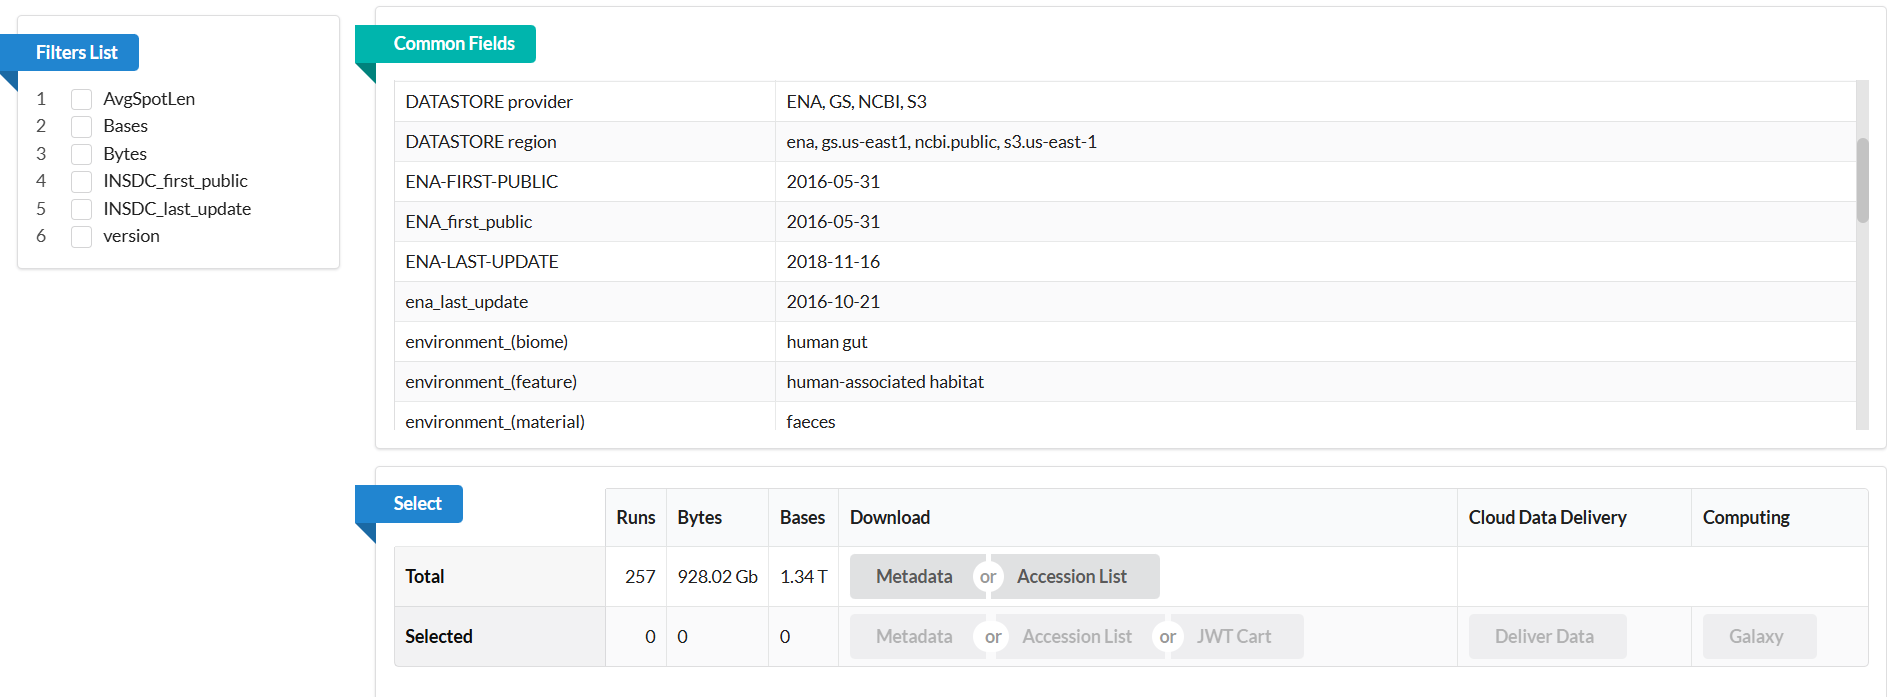

https://www.ebi.ac.uk/ena/browser/view/PRJEB26832
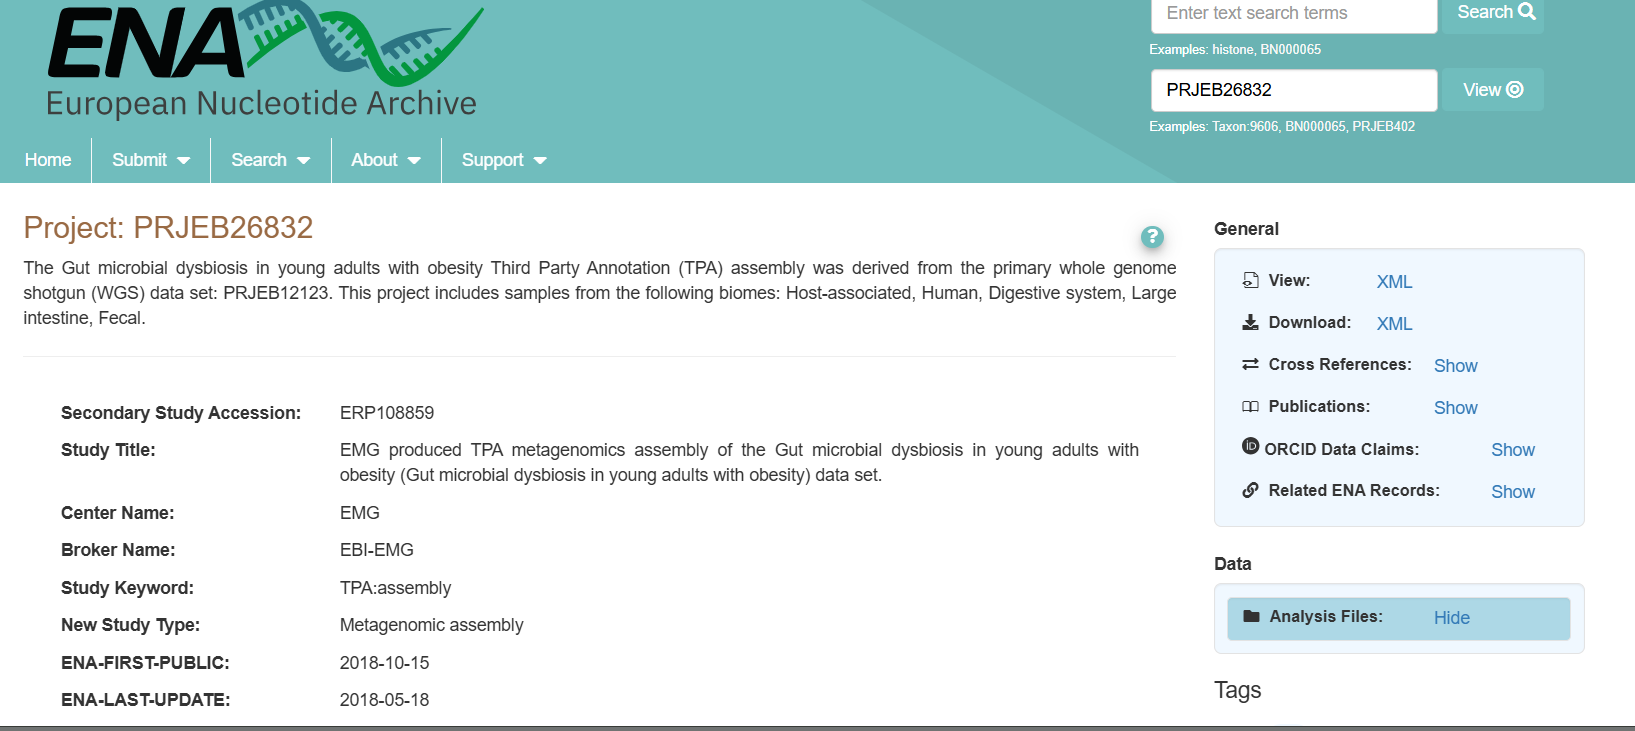

https://www.nature.com/articles/nm.4358#Sec40
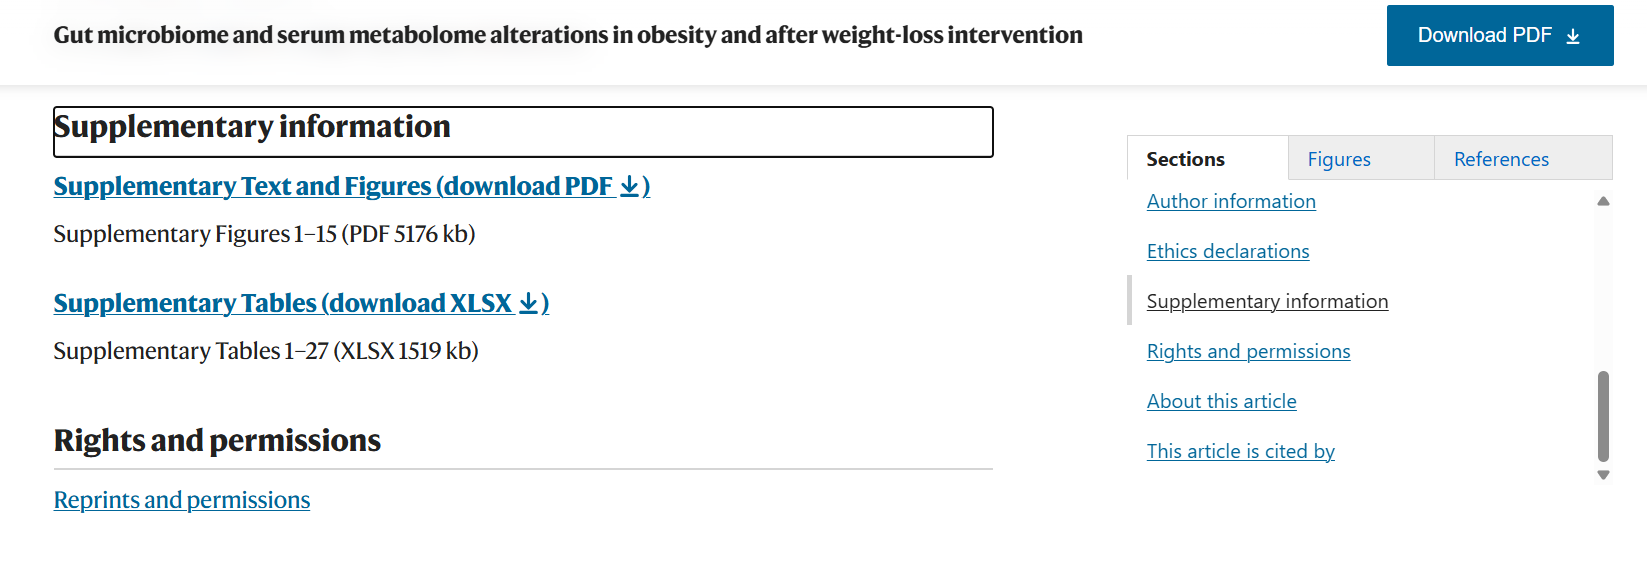

In [20]:
import pandas as pd

In [21]:
huth = pd.read_csv('../data/processed/huth_count_obesity_1/huth_count_obesity_1.csv')

In [22]:
huth.head()

,bacteria,huth,analysis,sample
0,Bacteroidaceae,hutH,MGYA00721508,ERZ650890
1,Bacteroidaceae,hutH,MGYA00721508,ERZ650890
2,Bacteria,hutH,MGYA00721508,ERZ650890
3,Bacteroidaceae,hutH,MGYA00721508,ERZ650890
4,Clostridiales incertae sedis,hutH,MGYA00721508,ERZ650890


In [23]:
ena_metadata = pd.read_csv('../data/raw/Estudio 1 obesidad material tablas complementarias/filereport_analysis_PRJEB26832 (2).tsv',sep='\t')

In [24]:
ena_metadata.head()

,analysis_accession,study_accession,secondary_study_accession,sample_accession,secondary_sample_accession,analysis_title,analysis_type,assembly_type,center_name,first_public,...,submitted_bytes,submitted_md5,submitted_ftp,submitted_aspera,submitted_galaxy,sample_alias,broker_name,sample_title,generated_file_role,submitted_file_role
0,ERZ1742295,PRJEB26832,ERP108859,SAMEA3708587,ERS1015736,Genome assembly: ERR1190661_6c944896a723178e53...,SEQUENCE_ASSEMBLY,primary metagenome,EMG,2021-03-01,...,73100499,6c944896a723178e531b33bf2fe9502c,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,fasp.sra.ebi.ac.uk:/vol1/analysis/ERZ174/ERZ17...,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,RSZAXPI001940-27,EBI-EMG,Stool sample from China,GENERATED_FILE,SUBMISSION_FILE
1,ERZ1742297,PRJEB26832,ERP108859,SAMEA3708701,ERS1015850,Genome assembly: ERR1190775_605d2ea76ceee25482...,SEQUENCE_ASSEMBLY,primary metagenome,EMG,2021-03-01,...,34168372,605d2ea76ceee25482f53f007f67a63f,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,fasp.sra.ebi.ac.uk:/vol1/analysis/ERZ174/ERZ17...,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,SZAXPI021994-25,EBI-EMG,Stool sample from China,GENERATED_FILE,SUBMISSION_FILE
2,ERZ1742298,PRJEB26832,ERP108859,SAMEA3708655,ERS1015804,Genome assembly: ERR1190729_8aa0e99bb2bc462f6d...,SEQUENCE_ASSEMBLY,primary metagenome,EMG,2021-03-01,...,58120829,8aa0e99bb2bc462f6db37ce56bc32036,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,fasp.sra.ebi.ac.uk:/vol1/analysis/ERZ174/ERZ17...,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,RSZAXPI005371-35,EBI-EMG,Stool sample from China,GENERATED_FILE,SUBMISSION_FILE
3,ERZ1742299,PRJEB26832,ERP108859,SAMEA3708525,ERS1015674,Genome assembly: ERR1190599_26d187c44c95bd53ce...,SEQUENCE_ASSEMBLY,primary metagenome,EMG,2021-03-01,...,66367869,26d187c44c95bd53ce3234471b1fccf9,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,fasp.sra.ebi.ac.uk:/vol1/analysis/ERZ174/ERZ17...,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,RSZAXPI001875-22,EBI-EMG,Stool sample from China,GENERATED_FILE,SUBMISSION_FILE
4,ERZ1742301,PRJEB26832,ERP108859,SAMEA3708554,ERS1015703,Genome assembly: ERR1190628_1f63f99455c99686e7...,SEQUENCE_ASSEMBLY,primary metagenome,EMG,2021-03-01,...,78151818,1f63f99455c99686e7601154e406eac1,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,fasp.sra.ebi.ac.uk:/vol1/analysis/ERZ174/ERZ17...,ftp.sra.ebi.ac.uk/vol1/analysis/ERZ174/ERZ1742...,RSZAXPI001907-97,EBI-EMG,Stool sample from China,GENERATED_FILE,SUBMISSION_FILE


In [25]:
ncbi_metadata = pd.read_csv('../data/raw/Estudio 1 obesidad material tablas complementarias/SraRunTable.csv')
ncbi_metadata.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Collection_Date,common_name,...,Platform,project_name,ReleaseDate,Sample Name,Sample_name,Sequencing_method,SRA Study,Submitter_Id,create_date,version
0,ERR1190532,WGS,196,5381763087,PRJEB12123,SAMEA3708458,3952832367,BEIJING GENOME INSTITUTE,2014,DB44,...,MetaHIT-IGC,2016-06-01T00:00:00Z,SAMEA3708458,RSZAXPI001806-13,Illumina,ERP013562,RSZAXPI001806-13,2016-06-03T17:21:00Z,1.0,NaN
1,ERR1190533,WGS,198,5110754235,PRJEB12123,SAMEA3708459,3655952325,BEIJING GENOME INSTITUTE,2014,DB45,...,MetaHIT-IGC,2016-06-01T00:00:00Z,SAMEA3708459,RSZAXPI001807-14,Illumina,ERP013562,RSZAXPI001807-14,2016-06-04T01:59:00Z,1.0,NaN
2,ERR1190534,WGS,198,4198142739,PRJEB12123,SAMEA3708460,2945638954,BEIJING GENOME INSTITUTE,2014,DB46,...,MetaHIT-IGC,2016-06-01T00:00:00Z,SAMEA3708460,RSZAXPI001808-15,Illumina,ERP013562,RSZAXPI001808-15,2016-06-02T06:02:00Z,1.0,NaN
3,ERR1190535,WGS,197,4918744791,PRJEB12123,SAMEA3708461,3579111089,BEIJING GENOME INSTITUTE,2014,DB47,...,MetaHIT-IGC,2016-06-01T00:00:00Z,SAMEA3708461,RSZAXPI001809-16,Illumina,ERP013562,RSZAXPI001809-16,2016-06-02T06:02:00Z,1.0,NaN
4,ERR1190536,WGS,196,4749846531,PRJEB12123,SAMEA3708462,3529092286,BEIJING GENOME INSTITUTE,2014,DB48,...,MetaHIT-IGC,2016-06-01T00:00:00Z,SAMEA3708462,RSZAXPI001810-17,Illumina,ERP013562,RSZAXPI001810-17,2016-06-02T06:02:00Z,1.0,NaN


In [26]:
ena = ena_metadata.iloc[:,[0,3]]
ncbi = ncbi_metadata.loc[:,['BioSample','common_name']]

In [27]:
df_new = pd.merge(left=ena,right=ncbi,how='inner',left_on='sample_accession',right_on='BioSample')

In [28]:
df_new.head()

,analysis_accession,sample_accession,BioSample,common_name
0,ERZ1742295,SAMEA3708587,SAMEA3708587,CON-D62
1,ERZ1742297,SAMEA3708701,SAMEA3708701,CON-D7
2,ERZ1742298,SAMEA3708655,SAMEA3708655,DB-S1-212
3,ERZ1742299,SAMEA3708525,SAMEA3708525,DB117
4,ERZ1742301,SAMEA3708554,SAMEA3708554,CON-D29


In [29]:
df_new = df_new.drop(columns=['sample_accession','BioSample'])

In [30]:
df_new.shape

(510, 2)

In [31]:
df_new['common_name'].nunique()

257

In [32]:
def map_common_name_column(text):
    
    text = str(text).strip()

    if text.startswith('DB-S'):
        mes = text[4]
        return f'SURGERY {mes}'

    elif text.startswith('DB'):
        return 'DISBIOSIS'
    
    elif text.startswith('CON'):
        return 'CONTROL'
    
    else:
        return 'unknown' 
    


In [33]:
df_new['common_name'] = df_new['common_name'].apply(map_common_name_column)

In [34]:
df_new['common_name'].value_counts()

common_name
DISBIOSIS    222
CONTROL      208
SURGERY 3     44
SURGERY 1     34
SURGERY 2      2
Name: count, dtype: int64

In [36]:
df_new.rename(columns={'common_name':'group'},inplace=True)

In [37]:
df_new.head()

,analysis_accession,group
0,ERZ1742295,CONTROL
1,ERZ1742297,CONTROL
2,ERZ1742298,SURGERY 1
3,ERZ1742299,DISBIOSIS
4,ERZ1742301,CONTROL


In [38]:
final_df = pd.merge(left=huth,right=df_new,left_on='sample',right_on='analysis_accession',how='left')

In [39]:
final_df.head()

,bacteria,huth,analysis,sample,analysis_accession,group
0,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,ERZ650890,DISBIOSIS
1,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,ERZ650890,DISBIOSIS
2,Bacteria,hutH,MGYA00721508,ERZ650890,ERZ650890,DISBIOSIS
3,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,ERZ650890,DISBIOSIS
4,Clostridiales incertae sedis,hutH,MGYA00721508,ERZ650890,ERZ650890,DISBIOSIS


In [44]:
sum(final_df['group'].isna())

0

In [45]:
final_df.drop(columns='analysis_accession',inplace=True)

In [48]:
final_df.sample(5)

,bacteria,huth,analysis,sample,group
4855,Porphyromonadaceae,hutH,MGYA00774903,ERZ650706,CONTROL
4093,Bacteroidaceae,hutH,MGYA00721956,ERZ650683,CONTROL
3844,Bacteroidaceae,hutH1,MGYA00721943,ERZ1742298,SURGERY 1
5739,Bacteroidaceae,hutH,MGYA00721775,ERZ650798,DISBIOSIS
3775,Bacteroidia,hutH,MGYA00721938,ERZ650682,DISBIOSIS


In [51]:
final_df['group'].value_counts()

group
CONTROL      2838
DISBIOSIS    2479
SURGERY 3     693
SURGERY 1     363
SURGERY 2      33
Name: count, dtype: int64

In [52]:
final_df.to_csv('../data/processed/huth_count_obesity_1/huth_count_adults_with_disbiosis.csv',index=False)

## __Representing data visually__

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('../data/processed/huth_count_obesity_1/huth_count_adults_with_disbiosis.csv')

In [22]:
df.head()

,bacteria,huth,analysis,sample,group
0,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,DISBIOSIS
1,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,DISBIOSIS
2,Bacteria,hutH,MGYA00721508,ERZ650890,DISBIOSIS
3,Bacteroidaceae,hutH,MGYA00721508,ERZ650890,DISBIOSIS
4,Clostridiales incertae sedis,hutH,MGYA00721508,ERZ650890,DISBIOSIS


In [23]:

key = df.groupby('group')['sample'].nunique()
conversion = {k: int(key.iloc[i]) for i,k in enumerate(key.index,0)}
conversion

{'CONTROL': 100,
 'DISBIOSIS': 103,
 'SURGERY 1': 14,
 'SURGERY 2': 1,
 'SURGERY 3': 21}

In [24]:
df['bacteria'].value_counts().head()

bacteria
Bacteroidaceae        2489
Porphyromonadaceae     784
Rikenellaceae          463
Oscillospiraceae       359
Bacteroidia            246
Name: count, dtype: int64

1. Preparar datos: Total de huth por grupo (Normalizado)

In [25]:
df_group_summary = df.groupby('group').size().reset_index(name='total_huth_reads')
df_group_summary['group_population'] = df_group_summary['group'].map(conversion)
df_group_summary['huth_normalized_abundance'] = df_group_summary['total_huth_reads'] / df_group_summary['group_population']

In [26]:
df_group_summary

,group,total_huth_reads,group_population,huth_normalized_abundance
0,CONTROL,2838,100,28.380000
1,DISBIOSIS,2479,103,24.067961
2,SURGERY 1,363,14,25.928571
3,SURGERY 2,33,1,33.000000
4,SURGERY 3,693,21,33.000000


<Axes: xlabel='group', ylabel='huth_normalized_abundance'>

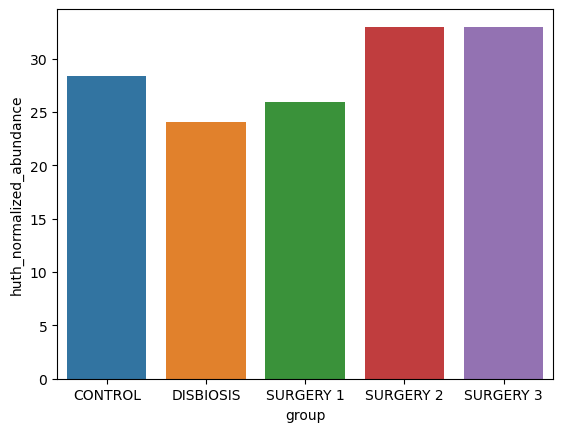

In [27]:
sns.barplot(data=df_group_summary,x='group',y='huth_normalized_abundance',hue = 'group',palette='tab10',legend=False)

2. Preparar datos: huth por bacteria y grupo (Normalizado)

In [28]:
df_bac_group = df.groupby(['bacteria','group']).size().reset_index(name='absolute_count')
df_bac_group['group_population'] = df_bac_group['group'].map(conversion)
df_bac_group['huth_normalized_abundance'] = df_bac_group['absolute_count'] / df_bac_group['group_population']

In [29]:
df_bac_group.head()

,bacteria,group,absolute_count,group_population,huth_normalized_abundance
0,Actinobacteria,DISBIOSIS,1,103,0.009709
1,Alloprevotella,CONTROL,2,100,0.020000
2,Alloprevotella,DISBIOSIS,1,103,0.009709
3,Alloprevotella,SURGERY 3,1,21,0.047619
4,Bacilli,CONTROL,6,100,0.060000


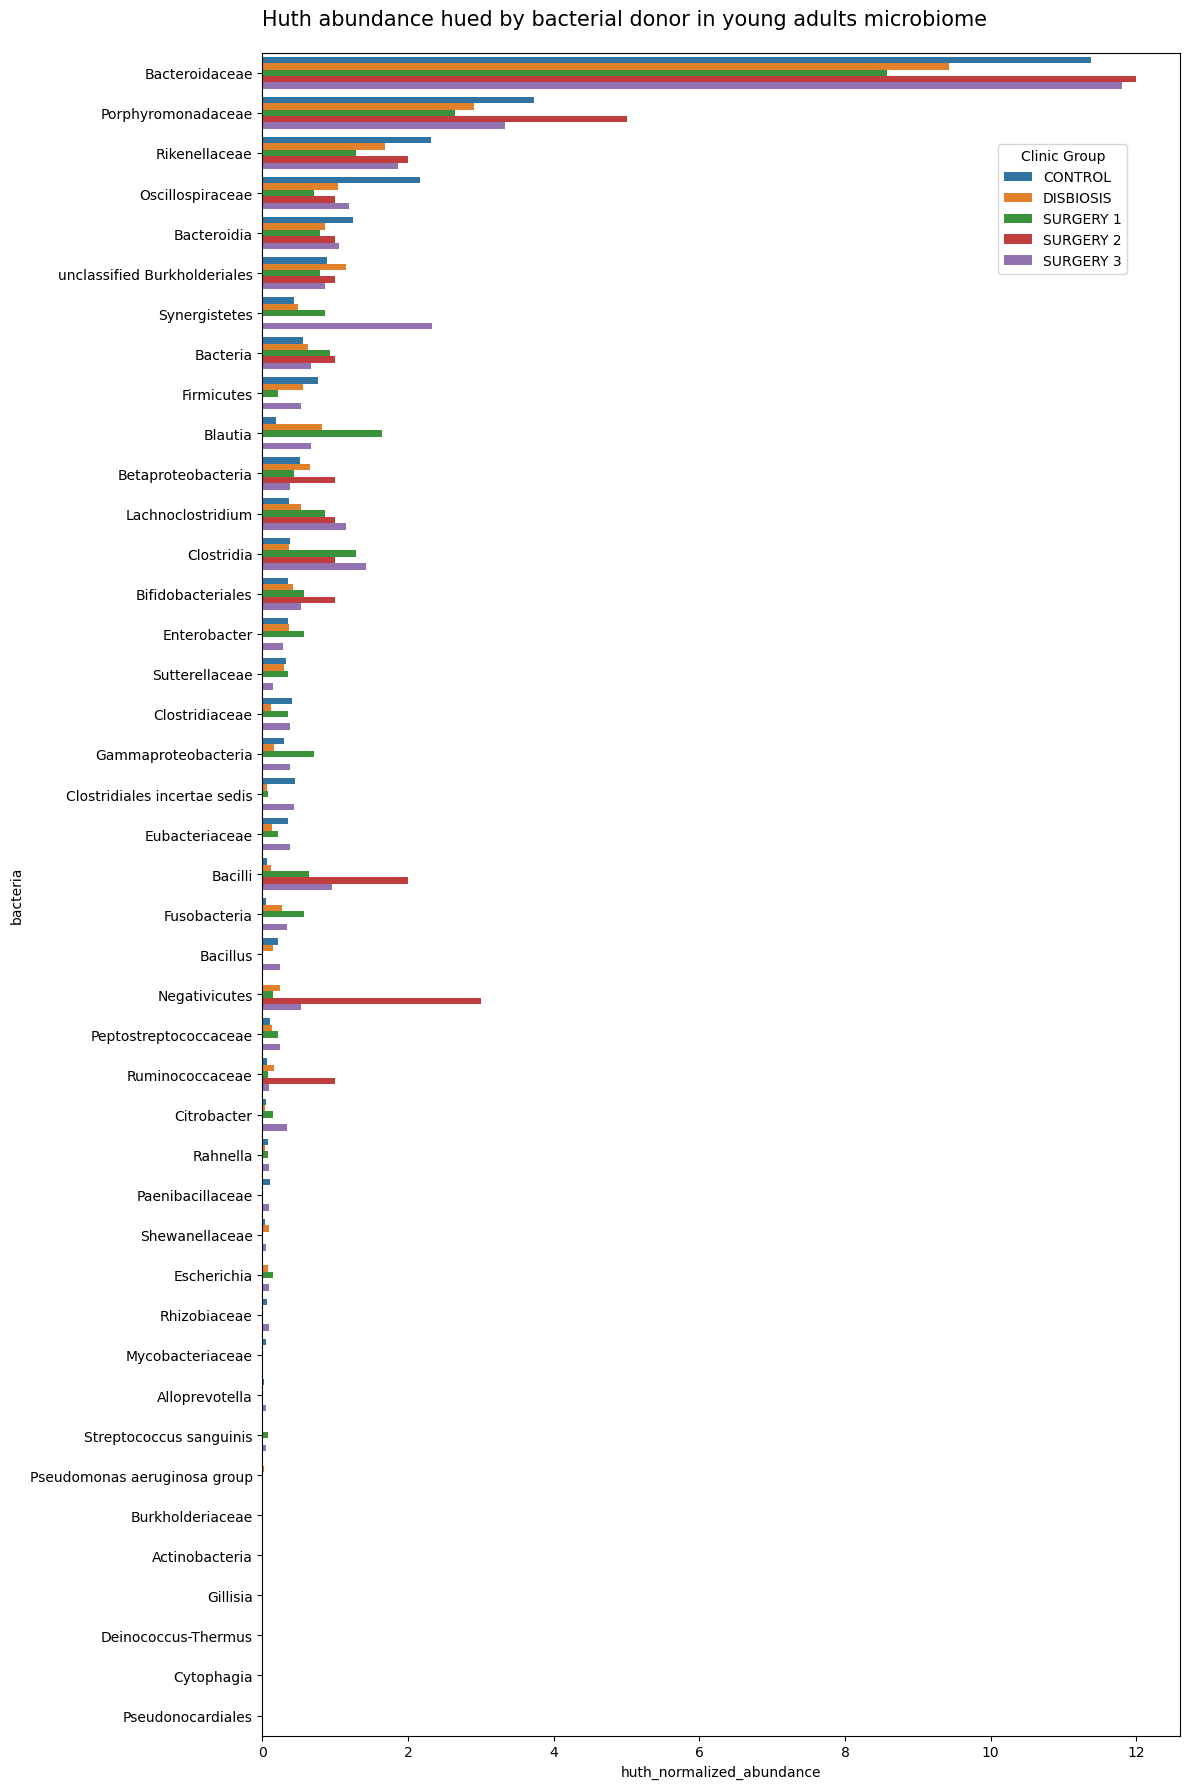

In [30]:
fig,axs = plt.subplots(1,1,figsize=(12,18))
order = df.value_counts('bacteria').index
hue_order =  ['CONTROL','DISBIOSIS','SURGERY 1','SURGERY 2','SURGERY 3']
axs.set_title('Huth abundance hued by bacterial donor in young adults microbiome',fontsize=15,fontweight=10,pad=20,loc='left')
sns.barplot(data=df_bac_group,x='huth_normalized_abundance',y='bacteria',hue = 'group',palette='tab10',ax=axs,order=order,hue_order=hue_order)
axs.legend(bbox_to_anchor=(0.95, 0.95), title='Clinic Group')
plt.tight_layout()

3. Preparar datos: Profundizar en el grupo más representativo

In [31]:
third_graph_df = df_bac_group[df_bac_group['group'] =='CONTROL' ].copy()

In [37]:
df[df['bacteria'] == 'Actinobacteria'] 

,bacteria,huth,analysis,sample,group
1597,Actinobacteria,hutH,MGYA00721828,ERZ650819,DISBIOSIS


In [32]:

order = df.value_counts('bacteria').index
n_bacterias = len(order)
color_list = []
color_list.extend(sns.color_palette("tab20"))
color_list.extend(sns.color_palette("tab20b"))
color_list.extend(sns.color_palette("tab20c"))
color_map = {bacteria:color_list[i] for i,bacteria in enumerate(order)}

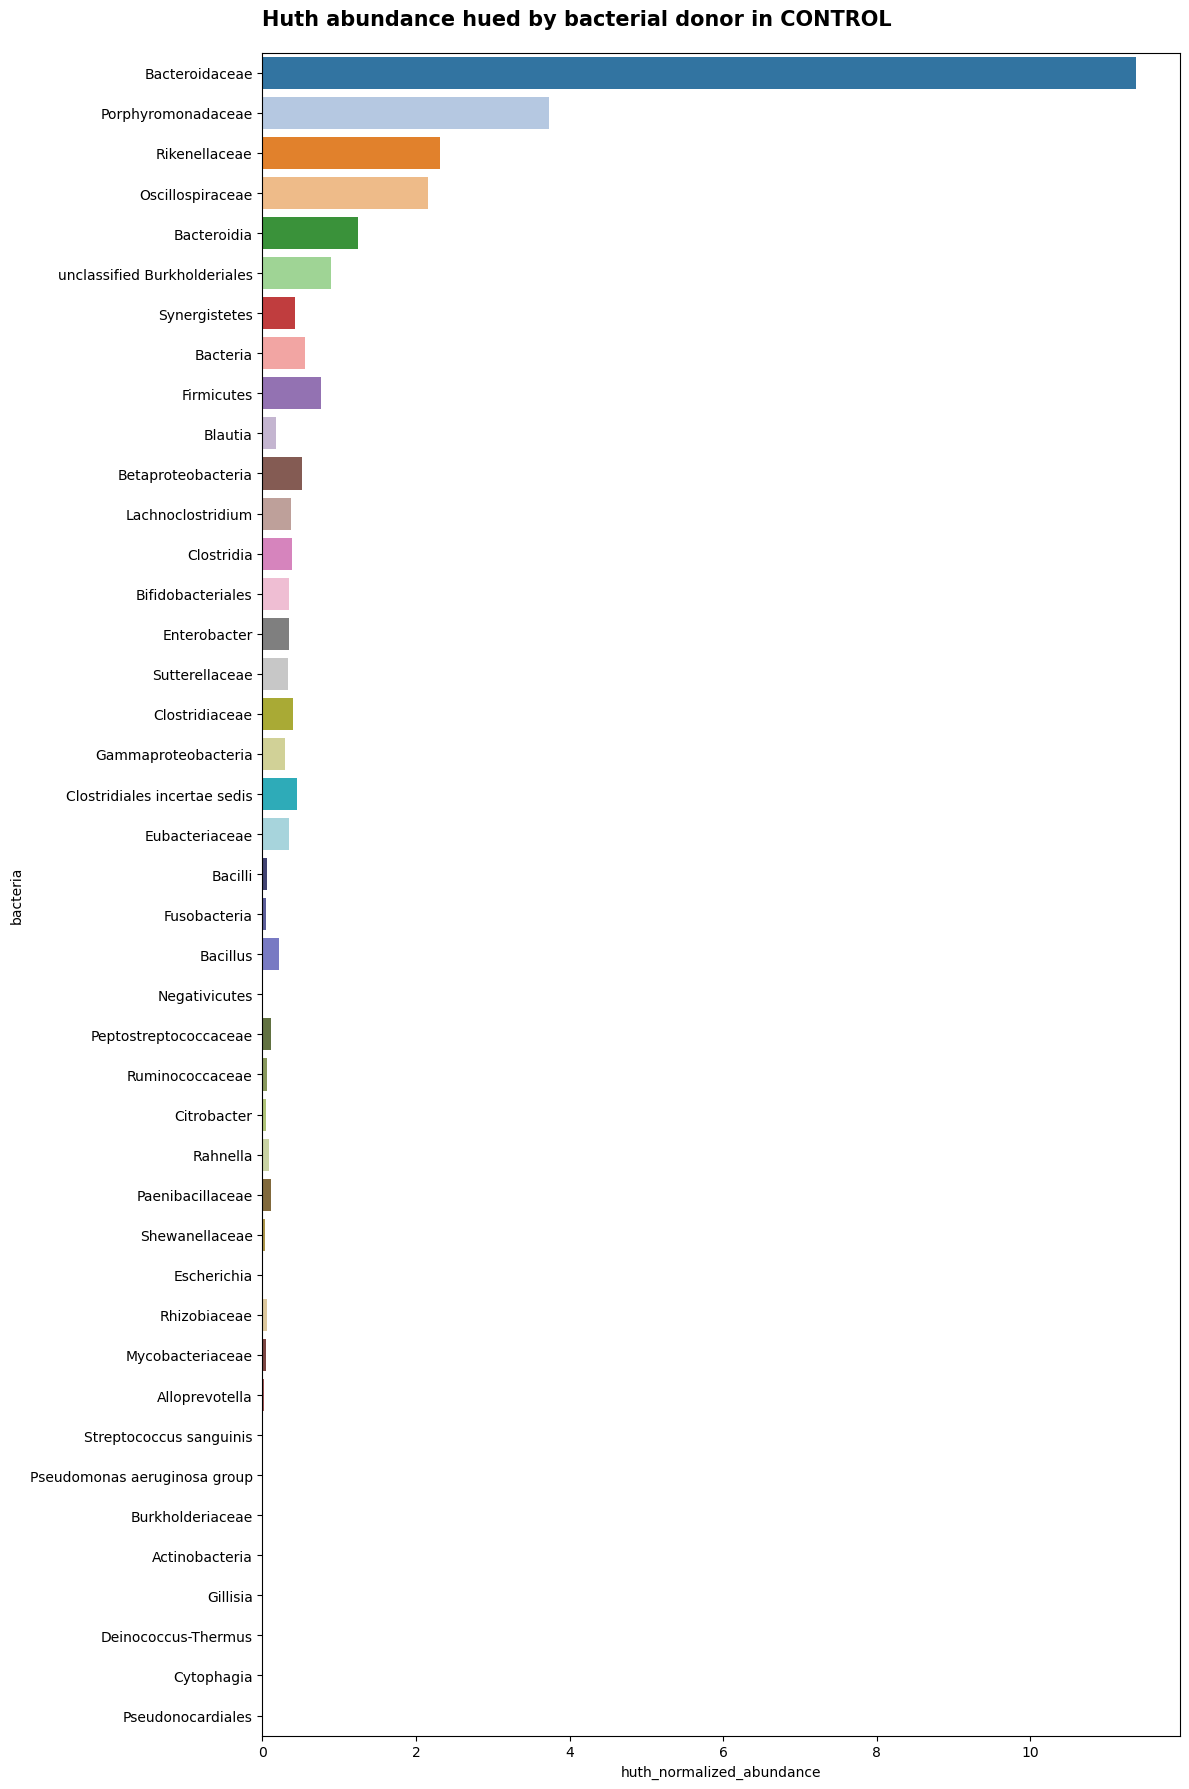

In [33]:
fig,axs = plt.subplots(1,1,figsize=(12,18))
order = df.value_counts('bacteria').index
hue_order =  ['CONTROL','DISBIOSIS','SURGERY 1','SURGERY 2','SURGERY 3']
axs.set_title('Huth abundance hued by bacterial donor in CONTROL',fontsize=15,fontweight=1000,pad=20,loc='left')
sns.barplot(data=third_graph_df,x='huth_normalized_abundance',y='bacteria',hue = 'bacteria',palette=color_map,ax=axs,order=order)
plt.tight_layout()

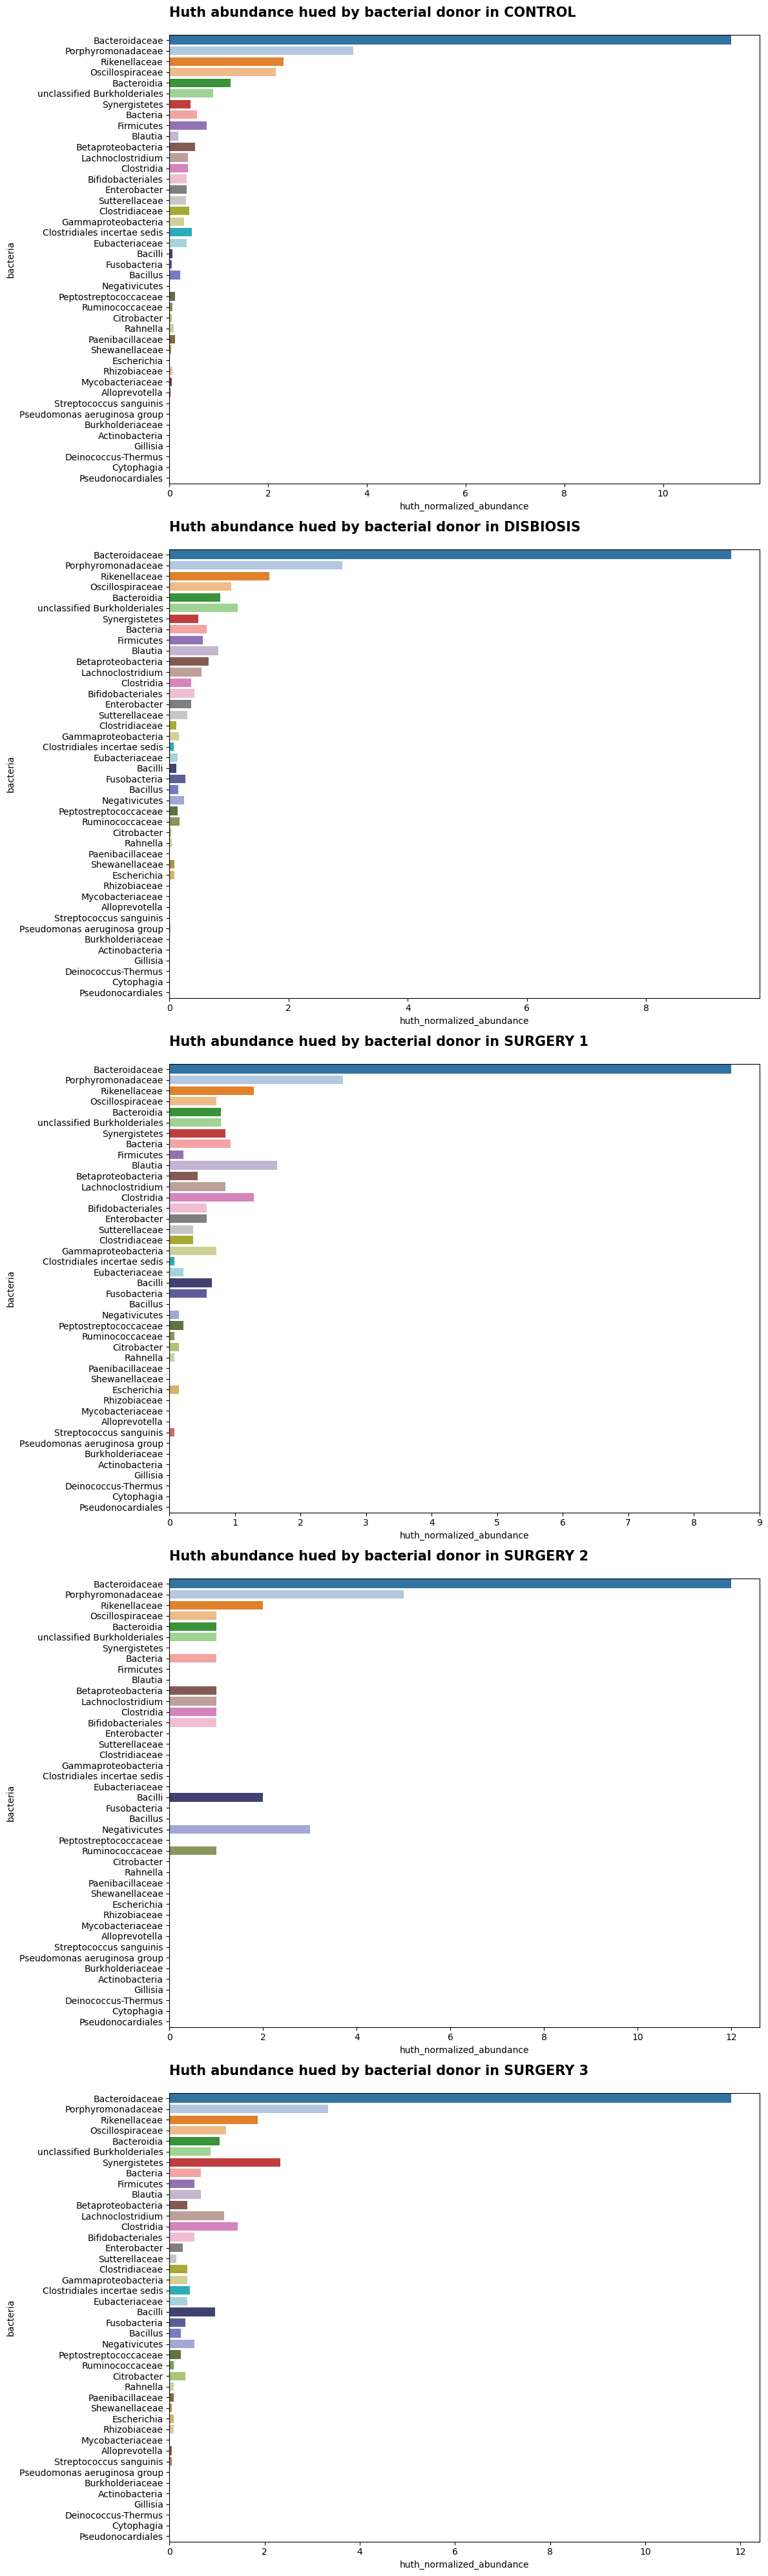

In [34]:
groups = ['CONTROL','DISBIOSIS','SURGERY 1','SURGERY 2','SURGERY 3']

order = df.value_counts('bacteria').index

fig,axs = plt.subplots(len(groups),1,figsize=(12,40))
for i in range(0,len(groups)):
    group = df_bac_group[df_bac_group['group'] == groups[i] ]
    axs[i].set_title(f'Huth abundance hued by bacterial donor in {groups[i]}',fontsize=15,fontweight=1000,pad=20,loc='left')
    sns.barplot(data=df_bac_group[df_bac_group['group'] == groups[i] ],x='huth_normalized_abundance',y='bacteria',hue = 'bacteria',palette=color_map,ax=axs[i],order=order)
plt.tight_layout()

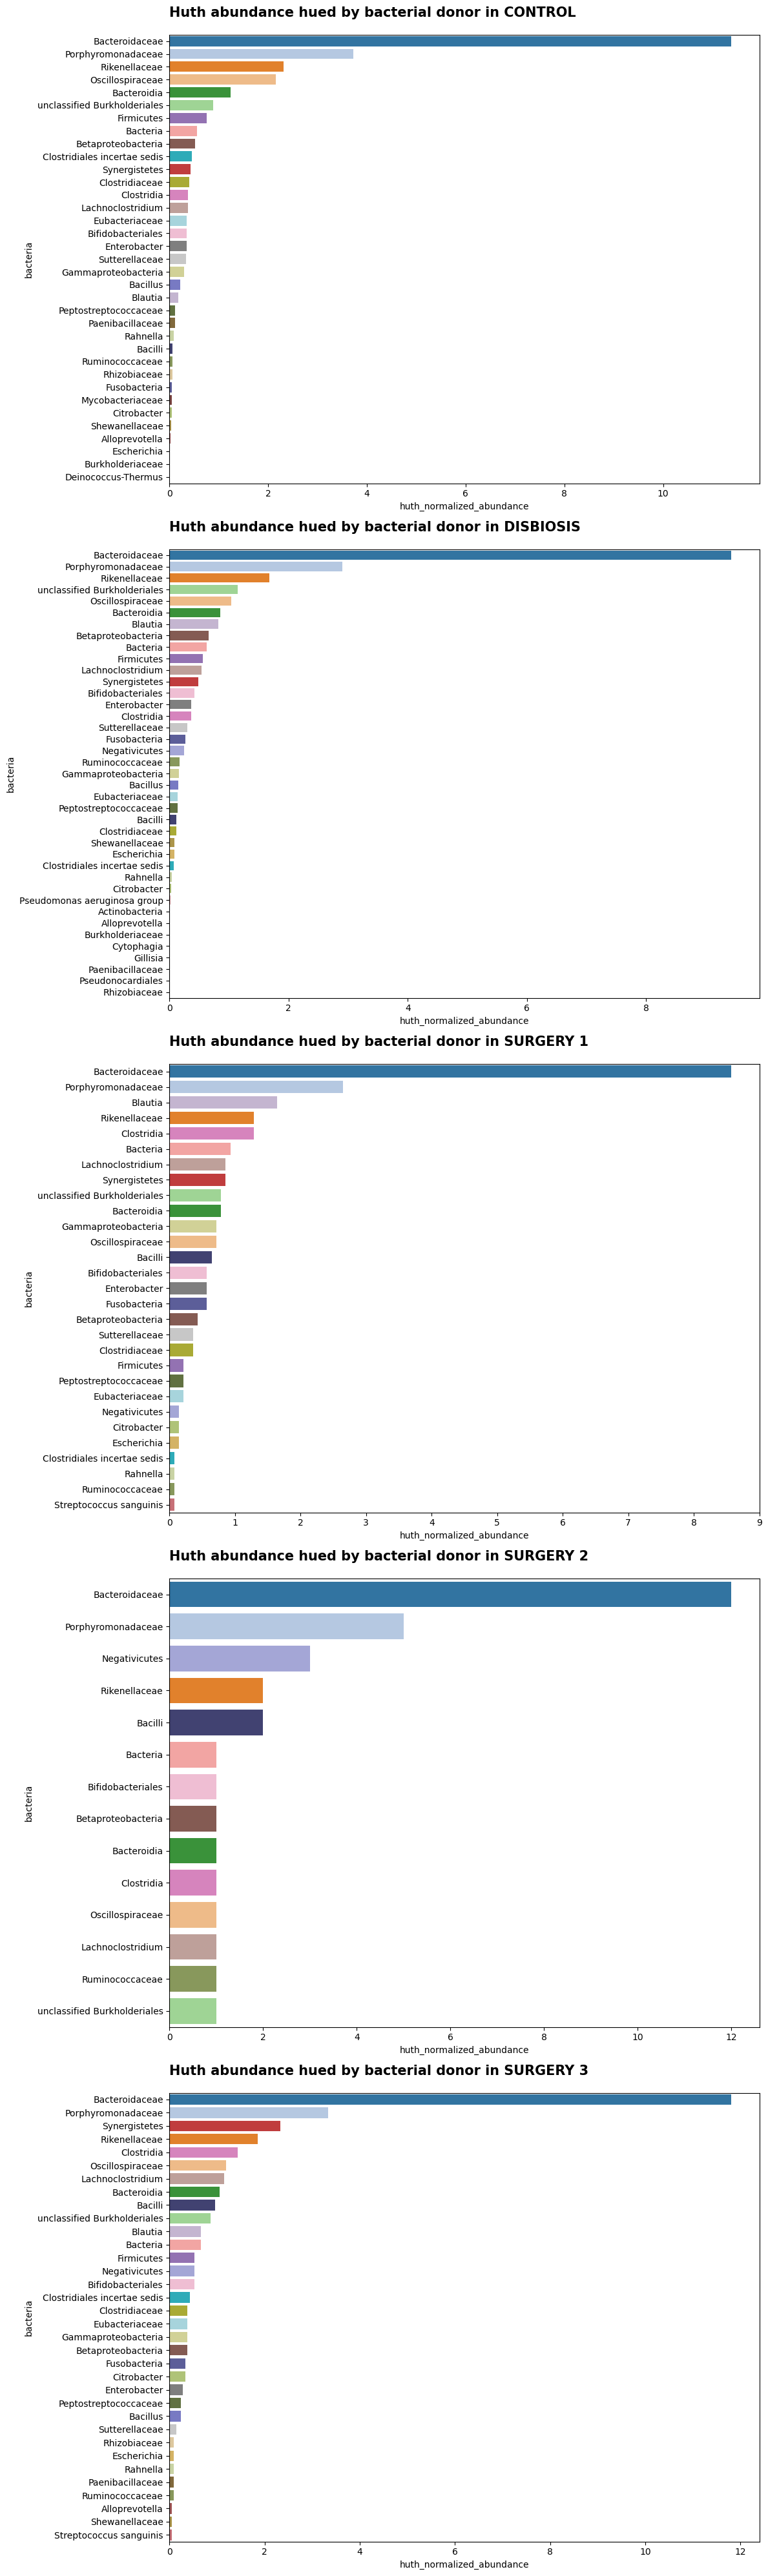

In [44]:
groups = ['CONTROL','DISBIOSIS','SURGERY 1','SURGERY 2','SURGERY 3']

fig,axs = plt.subplots(len(groups),1,figsize=(12,40))
for i in range(0,len(groups)):
    group = df_bac_group[df_bac_group['group'] == groups[i] ]
    order = group.groupby('bacteria')['huth_normalized_abundance'].sum().sort_values(ascending=False).index
    axs[i].set_title(f'Huth abundance hued by bacterial donor in {groups[i]}',fontsize=15,fontweight=1000,pad=20,loc='left')
    sns.barplot(data=df_bac_group[df_bac_group['group'] == groups[i] ],x='huth_normalized_abundance',y='bacteria',hue = 'bacteria',palette=color_map,ax=axs[i],order=order)
plt.tight_layout()